In [1]:
import pandas as pd
import os
import pyarrow.parquet as pq



common_stage_path = '/home/bbe9928/HIRID-ICU-Benchmark/real_data_wdir/common_stage'
files = sorted(os.listdir(common_stage_path))
print(f"Number of files: {len(files)}")
print("First few files:", files[:5])

table = pq.read_table(f"{common_stage_path}/{files[0]}")
df = table.to_pandas()
print(df.shape)
df.head(10)

Number of files: 250
First few files: ['part-0.parquet', 'part-1.parquet', 'part-10.parquet', 'part-100.parquet', 'part-101.parquet']
(91798, 203)


,patientid,datetime,HR,T Central,ABPs,ABPd,ABPm,NIBPs,NIBPd,NIBPm,...,Terlipressin,Immunoglobulin,Immunsuppression,VitB Substitution,Parkinson Medikaiton,GCSF,admissiontime,age,sex,height
0,148,0.0,98.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,162.0,50,M,NaN
1,148,5.0,119.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,162.0,50,M,NaN
2,148,10.0,127.0,NaN,155.0,99.0,119.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,162.0,50,M,NaN
3,148,15.0,119.0,NaN,150.0,99.0,117.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,162.0,50,M,NaN
4,148,20.0,118.0,NaN,151.0,99.0,117.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,162.0,50,M,NaN
5,148,25.0,116.0,NaN,145.0,88.0,112.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,162.0,50,M,NaN
6,148,30.0,105.0,NaN,116.0,74.0,87.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,162.0,50,M,NaN
7,148,35.0,101.0,NaN,110.0,70.0,83.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,162.0,50,M,NaN
8,148,40.0,100.0,NaN,103.0,64.0,77.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,162.0,50,M,NaN
9,148,45.0,97.0,NaN,99.0,61.0,73.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,162.0,50,M,NaN


In [5]:
general = pd.read_csv('/home/bbe9928/hirid_raw/general_table.csv')
print(general.columns.tolist())
print(general.head())

['patientid', 'admissiontime', 'sex', 'age', 'discharge_status']
   patientid        admissiontime sex  age discharge_status
0          1  2197-04-03 19:15:00   M   75            alive
1          2  2117-10-18 22:35:00   M   80            alive
2          3  2163-10-17 19:15:00   M   55            alive
3          4  2149-01-08 15:30:00   M   75            alive
4          5  2144-06-06 16:15:00   M   20            alive


In [6]:
varref = pd.read_csv('/home/bbe9928/hirid_raw/hirid_variable_reference.csv')
print(varref.columns.tolist())
# Search for apache
apache_vars = varref[varref['variablename'].str.lower().str.contains('apache', na=False)]
print(apache_vars)

['Source Table', 'ID', 'Variable Name', 'Unit', 'Additional information']


KeyError: 'variablename'

In [11]:
for i in range(len(df.columns)):
    print(f'{i}: {df.columns[i]}')

0: patientid
1: datetime
2: HR
3: T Central
4: ABPs
5: ABPd
6: ABPm
7: NIBPs
8: NIBPd
9: NIBPm
10: PAPm
11: PAPs
12: PAPd
13: PCWP
14: CO
15: SvO2(m)
16: ZVD
17: ST1
18: ST2
19: ST3
20: Rhythmus
21: SpO2
22: ETCO2
23: RR
24: supplemental oxygen
25: OUTurine/h
26: GCS Antwort
27: GCS Motorik
28: GCS Augen�ffnen
29: RASS
30: ICP
31: TOF
32: IN
33: OUT
34: Incrys
35: Incolloid
36: FIO2
37: Peep
38: Ventilator mode
39: TV
40: Spitzendruck
41: Plateaudruck
42: AWPmean
43: RR set
44: AiwayCode
45: Haemofiltration
46: Liquor/h
47: Weight
48: a-BE
49: a_COHb
50: a_Hb
51: a_HCO3-
52: a_Lac
53: a_MetHb
54: a_pH
55: a_pCO2
56: a_PO2
57: a_SO2
58: Zentral venöse sättigung
59: Troponin-T
60: creatine kinase
61: creatine kinase-MB
62: v-Lac
63: BNP
64: K+
65: Na+
66: Cl-
67: Ca2+ ionizied
68: Ca2+ total
69: phosphate
70: Mg_lab
71: Urea
72: creatinine
73: urinary creatinin
74: urinary Na+
75: urinary urea
76: ASAT
77: ALAT
78: bilirubine, total
79: Bilirubin, direct
80: alkaline phosphatase
81: gamm

In [10]:
import h5py
import hdf5plugin

f = h5py.File('/home/bbe9928/thesis_work/hirid_jepa/data/Cardiovascular_common_subset.h5', 'r')
columns = [c.decode('utf-8') for c in f['columns'][:]]
for i, c in enumerate(columns):
    print(f'{i}: {c}')
f.close()

0: datetime
1: HR
2: T Central
3: ABPs
4: ABPd
5: ABPm
6: NIBPs
7: NIBPd
8: NIBPm
9: PAPm
10: PAPs
11: PAPd
12: PCWP
13: CO
14: SvO2(m)
15: ZVD
16: ST1
17: ST2
18: ST3
19: Rhythmus
20: SpO2
21: ETCO2
22: RR
23: supplemental oxygen
24: OUTurine/h
25: GCS Antwort
26: GCS Motorik
27: GCS Augen�ffnen
28: RASS
29: ICP
30: TOF
31: IN
32: OUT
33: Incrys
34: Incolloid
35: FIO2
36: Peep
37: Ventilator mode
38: TV
39: Spitzendruck
40: Plateaudruck
41: AWPmean
42: RR set
43: AiwayCode
44: Haemofiltration
45: Liquor/h
46: Weight
47: a-BE
48: a_COHb
49: a_Hb
50: a_HCO3-
51: a_Lac
52: a_MetHb
53: a_pH
54: a_pCO2
55: a_PO2
56: a_SO2
57: Zentral venöse sättigung
58: Troponin-T
59: creatine kinase
60: creatine kinase-MB
61: v-Lac
62: BNP
63: K+
64: Na+
65: Cl-
66: Ca2+ ionizied
67: Ca2+ total
68: phosphate
69: Mg_lab
70: Urea
71: creatinine
72: urinary creatinin
73: urinary Na+
74: urinary urea
75: ASAT
76: ALAT
77: bilirubine, total
78: Bilirubin, direct
79: alkaline phosphatase
80: gamma-GT
81: aPTT


In [6]:
import pyarrow.parquet as pq
import pandas as pd
import numpy as np
import os

common_stage_path = '/home/bbe9928/HIRID-ICU-Benchmark/real_data_wdir/common_stage'
files = sorted(os.listdir(common_stage_path))
print(f"Number of batch files: {len(files)}")

# Load first batch
df = pq.read_table(f"{common_stage_path}/{files[0]}").to_pandas()
print(f"Shape: {df.shape}")
print(f"Columns ({len(df.columns)}): {df.columns.tolist()}")

Number of batch files: 250
Shape: (91798, 203)
Columns (203): ['patientid', 'datetime', 'HR', 'T Central', 'ABPs', 'ABPd', 'ABPm', 'NIBPs', 'NIBPd', 'NIBPm', 'PAPm', 'PAPs', 'PAPd', 'PCWP', 'CO', 'SvO2(m)', 'ZVD', 'ST1', 'ST2', 'ST3', 'Rhythmus', 'SpO2', 'ETCO2', 'RR', 'supplemental oxygen', 'OUTurine/h', 'GCS Antwort', 'GCS Motorik', 'GCS Augen�ffnen', 'RASS', 'ICP', 'TOF', 'IN', 'OUT', 'Incrys', 'Incolloid', 'FIO2', 'Peep', 'Ventilator mode', 'TV', 'Spitzendruck', 'Plateaudruck', 'AWPmean', 'RR set', 'AiwayCode', 'Haemofiltration', 'Liquor/h', 'Weight', 'a-BE', 'a_COHb', 'a_Hb', 'a_HCO3-', 'a_Lac', 'a_MetHb', 'a_pH', 'a_pCO2', 'a_PO2', 'a_SO2', 'Zentral venöse sättigung', 'Troponin-T', 'creatine kinase', 'creatine kinase-MB', 'v-Lac', 'BNP', 'K+', 'Na+', 'Cl-', 'Ca2+ ionizied', 'Ca2+ total', 'phosphate', 'Mg_lab', 'Urea', 'creatinine', 'urinary creatinin', 'urinary Na+', 'urinary urea', 'ASAT', 'ALAT', 'bilirubine, total', 'Bilirubin, direct', 'alkaline phosphatase', 'gamma-GT', 'aPT

In [1]:
import numpy as np
import h5py
import hdf5plugin
import matplotlib.pyplot as plt
from data.constants import MEASUREMENT_IDX, TREATMENT_IDX, DATETIME_IDX, DEMOGRAPHIC_IDX

f = h5py.File('/home/bbe9928/thesis_work/hirid_jepa/data/Cardiovascular_common_subset.h5', 'r')
columns = [c.decode('utf-8') for c in f['columns'][:]]
print(f'Should be datetime: datetime_idx[0] = {DATETIME_IDX[0]}')
print(columns[DATETIME_IDX[0]])      # should be datetime
print(f'Should be HR: Measurement_idx[0] = {MEASUREMENT_IDX[0]}')
print(columns[MEASUREMENT_IDX[0]])   # should be HR
print(columns[TREATMENT_IDX[0]])     # should be supplemental oxygen
print(columns[DEMOGRAPHIC_IDX[0]])   # should be Weight
f.close()

Should be datetime: datetime_idx[0] = 0
datetime
Should be HR: Measurement_idx[0] = 1
HR
supplemental oxygen
Weight


In [7]:
# Load ml_stage columns for comparison
import h5py, hdf5plugin
f = h5py.File('/home/bbe9928/thesis_work/hirid_jepa/data/Cardiovascular_subset.h5', 'r')
ml_columns = [c.decode('utf-8') for c in f['data']['columns'][:]]
f.close()

common_columns = df.columns.tolist()
common_columns_clean = [c for c in common_columns if c not in ['patientid', 'datetime']]

only_in_ml     = set(ml_columns) - set(common_columns_clean)
only_in_common = set(common_columns_clean) - set(ml_columns)
in_both        = set(ml_columns) & set(common_columns_clean)

print(f"Variables in ml_stage:     {len(ml_columns)}")
print(f"Variables in common_stage: {len(common_columns_clean)}")
print(f"In both:                   {len(in_both)}")
print(f"\nOnly in ml_stage (one-hot encoded or added):")
for c in sorted(only_in_ml): print(f"  {c}")
print(f"\nOnly in common_stage (raw, before one-hot):")
for c in sorted(only_in_common): print(f"  {c}")

Variables in ml_stage:     231
Variables in common_stage: 201
In both:                   139

Only in ml_stage (one-hot encoded or added):
  Acetazolamide_1.0
  Adenosin_1.0
  Administation of antimycotic_1.0
  Administriation of antibiotics_1.0
  AiwayCode_1.0
  AiwayCode_2.0
  AiwayCode_3.0
  AiwayCode_4.0
  AiwayCode_5.0
  AiwayCode_6.0
  Aldosteron Antagonist_1.0
  Amiodaron_1.0
  Andere_1.0
  Anexate_1.0
  Anti Fibrinolyticum_1.0
  Anti delirant medi_1.0
  Antihelmenticum_1.0
  Antihistaminka_1.0
  Atropin_1.0
  Barbiturate_1.0
  Beh. Pulm. Hypertonie_1.0
  Bicarbonate_1.0
  Ca_1.0
  Chemotherapie_1.0
  Digoxin_1.0
  Enteral Feeding_1.0
  GCSF_1.0
  Haemofiltration_1.0
  Immunoglobulin_1.0
  Immunsuppression_1.0
  K-sparend_1.0
  Kalium_1.0
  Lysetherapie_1.0
  Marcoumar_1.0
  Mg_1.0
  Mineralokortikoid_1.0
  Muskelrelaxans_1.0
  NMH_1.0
  NSAR_1.0
  Na_1.0
  Naloxon_1.0
  Nimodipin_1.0
  Non-opioide_1.0
  Others in Case of HIT_1.0
  Pankreas Enzyme_1.0
  Parenteral Feeding_1.0
  

In [3]:
print("Demographics columns:")
for i in [47, 199, 200, 201, 202]:
    print(f"  {i}: {df.columns[i]}")

print("\nFirst 5 measurement columns:")
for i in [2, 3, 4, 5, 6]:
    print(f"  {i}: {df.columns[i]}")

print("\nFirst 5 treatment columns:")
for i in [24, 32, 34, 35, 36]:
    print(f"  {i}: {df.columns[i]}")

print("\nSex column values:")
print(df['sex'].value_counts())

Demographics columns:
  47: Weight
  199: admissiontime
  200: age
  201: sex
  202: height

First 5 measurement columns:
  2: HR
  3: T Central
  4: ABPs
  5: ABPd
  6: ABPm

First 5 treatment columns:
  24: supplemental oxygen
  32: IN
  34: Incrys
  35: Incolloid
  36: FIO2

Sex column values:
sex
M    61805
F    29993
Name: count, dtype: int64


In [4]:
import pyarrow.parquet as pq
import pandas as pd
import numpy as np

# Load several batches for representative stats
dfs = []
for fname in sorted(os.listdir(common_stage_path))[:20]:
    dfs.append(pq.read_table(f"{common_stage_path}/{fname}").to_pandas())
sample = pd.concat(dfs, ignore_index=True)

MEASUREMENT_COLS = [df.columns[i] for i in [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16,
17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 31,
33, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58,
59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72,
73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86,
87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100,
101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111,
112, 113, 114]]

stats = pd.DataFrame({
    'obs_rate': (~sample[MEASUREMENT_COLS].isna()).mean(),
    'mean':     sample[MEASUREMENT_COLS].mean(),
    'std':      sample[MEASUREMENT_COLS].std(),
    'min':      sample[MEASUREMENT_COLS].min(),
    'max':      sample[MEASUREMENT_COLS].max(),
}).sort_values('obs_rate', ascending=False)

print(stats.head(20).to_string())

           obs_rate        mean         std        min           max
HR         0.974445   85.449424   17.907620   0.000000    300.000000
SpO2       0.931621   96.393899    3.528564  10.000000    100.000000
ABPs       0.884586  118.227118   27.437754  10.000000    300.000000
ABPm       0.884365   77.727217   17.021598  10.000000    200.000000
ABPd       0.884145   57.387353   13.163387  10.000000    175.000000
ST1        0.623663    0.041179    0.598870 -11.600000     10.500000
ZVD        0.598801    8.338919    5.202555   0.000000     50.000000
RR         0.490952   16.812416   10.072400   0.000000     45.000000
ST2        0.432999    0.120718    0.609167 -17.200001     16.400000
ETCO2      0.416478   29.621761    6.790129  10.000000    100.000000
ST3        0.366280    0.123476    0.516552 -17.200001     16.100000
T Central  0.128350   37.195734    0.944602  25.000000     44.799999
PAPs       0.110340   39.580004   12.111038  10.000000    150.000000
PAPm       0.110211   26.829304   

In [5]:
import pyarrow.parquet as pq
import pandas as pd
import numpy as np
import os

common_stage_path = '/home/bbe9928/HIRID-ICU-Benchmark/real_data_wdir/common_stage'

# Load the split file to know which patients are in train
split_df = pd.read_csv('/home/bbe9928/HIRID-ICU-Benchmark/preprocessing/resources/split.tsv', sep='\t')
print(split_df.head())
print(split_df['split'].value_counts())
print(f"Total patients: {len(split_df)}")

   Unnamed: 0  patientid  split
0           0        148  train
1           1        229  train
2           2        496  train
3           3        766  train
4           4       1342  train
split
train    23731
test      5086
val       5086
Name: count, dtype: int64
Total patients: 33903


In [6]:
sample = pq.read_table(f"{common_stage_path}/{files[0]}").to_pandas()
for col in sample.columns:
    if sample[col].dtype == object:
        print(f"{col}: {sample[col].unique()[:5]}")

sex: ['M' 'F']


In [2]:
import h5py
import hdf5plugin
import numpy as np

f = h5py.File('/home/bbe9928/thesis_work/hirid_jepa/data/common_stage_scaled.h5', 'r')

# Structure
print("Top level keys:", list(f.keys()))
print("\nData groups:", list(f['data'].keys()))
print("Mask groups:", list(f['mask'].keys()))
print("Window groups:", list(f['windows'].keys()))

# Shapes
for split in ['train', 'val', 'test']:
    d = f['data'][split]
    m = f['mask'][split]
    w = f['windows'][split]
    print(f"\n{split}:")
    print(f"  data shape:    {d.shape}")
    print(f"  mask shape:    {m.shape}")
    print(f"  windows shape: {w.shape}")

# Column names
columns = [c.decode('utf-8') for c in f['columns'][:]]
print(f"\nTotal columns: {len(columns)}")
print("First 10:", columns[:10])

# Verify mask is binary
train_mask = f['mask']['train'][:100]
print(f"\nMask unique values: {np.unique(train_mask)}")

# Verify scaling — HR should be roughly mean=0, std=1
hr_idx = columns.index('HR')
train_data = f['data']['train'][:10000, hr_idx]
mask_hr    = f['mask']['train'][:10000, hr_idx]
observed   = train_data[mask_hr == 1]
print(f"\nHR (observed only):")
print(f"  mean: {observed.mean():.3f}  (expected ~0)")
print(f"  std:  {observed.std():.3f}   (expected ~1)")

# Verify windows
train_windows = f['windows']['train'][:]
print(f"\nFirst 3 windows: {train_windows[:3]}")
print(f"Last window end matches data length: {train_windows[-1][1]} == {f['data']['train'].shape[0]}")

# Check a patient
start, end, pid = train_windows[0]
patient_data = f['data']['train'][start:end]
patient_mask = f['mask']['train'][start:end]
print(f"\nFirst patient (pid={pid}):")
print(f"  timesteps: {end-start}")
print(f"  mean obs rate: {patient_mask.mean():.3f}")
print(f"  HR obs rate:   {patient_mask[:, hr_idx].mean():.3f}")

f.close()

Top level keys: ['columns', 'data', 'mask', 'windows']

Data groups: ['test', 'train', 'val']
Mask groups: ['test', 'train', 'val']
Window groups: ['test', 'train', 'val']

train:
  data shape:    (15513124, 202)
  mask shape:    (15513124, 202)
  windows shape: (23727, 3)

val:
  data shape:    (3299634, 202)
  mask shape:    (3299634, 202)
  windows shape: (5085, 3)

test:
  data shape:    (3253059, 202)
  mask shape:    (3253059, 202)
  windows shape: (5086, 3)

Total columns: 202
First 10: ['datetime', 'HR', 'T Central', 'ABPs', 'ABPd', 'ABPm', 'NIBPs', 'NIBPd', 'NIBPm', 'PAPm']

Mask unique values: [0. 1.]

HR (observed only):
  mean: 0.282  (expected ~0)
  std:  1.022   (expected ~1)

First 3 windows: [[  0 265 148]
 [265 530 229]
 [530 820 496]]
Last window end matches data length: 15513124 == 15513124

First patient (pid=148):
  timesteps: 265
  mean obs rate: 0.068
  HR obs rate:   0.992


In [5]:
import h5py, hdf5plugin
import numpy as np

# Load windows from new file to get patient IDs
f_new = h5py.File('/home/bbe9928/thesis_work/hirid_jepa/data/common_stage_scaled.h5', 'r')
f_ml = h5py.File('/home/bbe9928/HIRID-ICU-Benchmark/real_data_wdir/ml_stage/ml_stage_12h.h5', 'r')

# Check patient ID overlap between common_stage and ml_stage
new_train_pids = set(f_new['windows']['train'][:, 2].tolist())
ml_train_pids  = set(f_ml['patient_windows']['train'][:, 2].tolist())

print(f"Common stage train patients: {len(new_train_pids)}")
print(f"ML stage train patients:     {len(ml_train_pids)}")
print(f"Overlap:                     {len(new_train_pids & ml_train_pids)}")

f_new.close()
f_ml.close()

Common stage train patients: 23727
ML stage train patients:     23727
Overlap:                     23727


Creating subset for: Cardiovascular
  train: 1703 patients, 1765089 timesteps
  val: 309 patients, 339749 timesteps
  test: 355 patients, 357182 timesteps
  Saved to /home/bbe9928/thesis_work/hirid_jepa/data/Cardiovascular_common_subset.h5

Creating subset for: Surgical_Neurological
  train: 778 patients, 1002324 timesteps
  val: 174 patients, 226979 timesteps
  test: 154 patients, 217388 timesteps
  Saved to /home/bbe9928/thesis_work/hirid_jepa/data/Surgical_Neurological_common_subset.h5



In [9]:
from data.constants import MEASUREMENT_IDX, TREATMENT_IDX

f = h5py.File('/home/bbe9928/thesis_work/hirid_jepa/data/Cardiovascular_common_subset.h5', 'r')
all_columns       = [c.decode('utf-8') for c in f['columns'][:]]
print(f"Column at MEASUREMENT_IDX[0]: {all_columns[MEASUREMENT_IDX[0]]}")
# HR should be at index 2 in the full column list
print(f"HR is at column index: {all_columns.index('HR')}")
print(f"Is HR index in MEASUREMENT_IDX: {all_columns.index('HR') in MEASUREMENT_IDX}")
print(f"Is HR index in TREATMENT_IDX: {all_columns.index('HR') in TREATMENT_IDX}")

Column at MEASUREMENT_IDX[0]: T Central
HR is at column index: 1
Is HR index in MEASUREMENT_IDX: False
Is HR index in TREATMENT_IDX: False


In [11]:
import h5py, hdf5plugin, numpy as np
f = h5py.File('/home/bbe9928/thesis_work/hirid_jepa/data/Cardiovascular_common_subset.h5', 'r')
data = f['data']['train'][:1000]
mask = f['mask']['train'][:1000]
print(f"NaN in data: {np.isnan(data).sum()}")
print(f"NaN in mask: {np.isnan(mask).sum()}")
print(f"Inf in data: {np.isinf(data).sum()}")

# Check demographics specifically
demo_data = f['data']['train'][:1000, DEMOGRAPHIC_IDX]
print(f"NaN in demographics: {np.isnan(demo_data).sum()}")
print(f"NaN per demographic column:")
for i, idx in enumerate(DEMOGRAPHIC_IDX):
    n_nan = np.isnan(demo_data[:, i]).sum()
    print(f"  {columns[idx]:20s}: {n_nan} NaNs")

f.close()

NaN in data: 90
NaN in mask: 0
Inf in data: 0
NaN in demographics: 0
NaN per demographic column:
  Weight              : 0 NaNs
  admissiontime       : 0 NaNs
  age                 : 0 NaNs
  sex                 : 0 NaNs
  height              : 0 NaNs


In [15]:
f = h5py.File('/home/bbe9928/thesis_work/hirid_jepa/data/Cardiovascular_common_subset.h5', 'r')
data = f['data']['train'][:1000]
mask = f['mask']['train'][:1000]

# Find where NaN exists despite mask=1
nan_positions = np.isnan(data)
nan_but_observed = nan_positions & (mask == 1)
print(f"NaN where mask=1: {nan_but_observed.sum()}")
print(f"NaN where mask=0: {(nan_positions & (mask == 0)).sum()}")

# Which columns have observed NaNs
for i in range(data.shape[1]):
    n = nan_but_observed[:, i].sum()
    if n > 0:
        print(f"  col {i} ({columns[i]}): {n} observed NaNs")
f.close()

NaN where mask=1: 0
NaN where mask=0: 0


In [8]:
print(f"Max MEASUREMENT_IDX: {max(MEASUREMENT_IDX)}")
print(f"Max TREATMENT_IDX: {max(TREATMENT_IDX)}")  
print(f"Max DEMOGRAPHIC_IDX: {max(DEMOGRAPHIC_IDX)}")
print(f"Total columns: {data.shape[1]}")

Max MEASUREMENT_IDX: 114
Max TREATMENT_IDX: 197
Max DEMOGRAPHIC_IDX: 201
Total columns: 202


## Subset Creation

In [3]:
import h5py, hdf5plugin
import numpy as np

f_new = h5py.File('/home/bbe9928/thesis_work/hirid_jepa/data/common_stage_scaled.h5', 'r')
f_ml  = h5py.File('/home/bbe9928/HIRID-ICU-Benchmark/real_data_wdir/ml_stage/ml_stage_12h.h5', 'r')

tasks        = [t.decode('utf-8') for t in f_ml['labels']['tasks'][:]]
apache_idx   = tasks.index('Phenotyping_APACHEGroup')

apache_names = {
    1: 'Cardiovascular', 2: 'Pulmonary', 3: 'Gastrointestinal',
    4: 'Neurological', 6: 'Sepsis_Other', 7: 'Trauma',
    8: 'Metabolic_Endocrinology', 9: 'Hematology',
    11: 'Surgical_Cardiovascular', 12: 'Surgical_Respiratory',
    13: 'Surgical_Gastrointestinal', 14: 'Surgical_Neurological',
    15: 'Surgical_Trauma', 16: 'Surgical_Urogenital',
    17: 'Surgical_Gynecology_Orthopedics'
}

def get_apache_label_per_patient(split, f_ml):
    """Returns dict of {pid: apache_label} for patients with a single apache label."""
    apache_col  = f_ml['labels'][split][:, apache_idx]
    windows     = f_ml['patient_windows'][split][:]
    pid_to_apache = {}
    for start, end, pid in windows:
        labels = apache_col[start:end]
        labels = labels[~np.isnan(labels)]
        unique = np.unique(labels)
        if len(unique) == 1:
            pid_to_apache[int(pid)] = int(unique[0])
    return pid_to_apache

def create_common_stage_subset(apache_group, f_new, f_ml, output_dir):
    group_name  = apache_names[apache_group].replace('/', '_')
    output_path = f"{output_dir}/{group_name}_common_subset.h5"
    print(f"Creating subset for: {group_name}")

    with h5py.File(output_path, 'w') as f_out:
        # Copy columns
        f_out.create_dataset('columns', data=f_new['columns'][:])

        for split in ['train', 'val', 'test']:
            pid_to_apache = get_apache_label_per_patient(split, f_ml)
            target_pids   = {pid for pid, label in pid_to_apache.items()
                             if label == apache_group}

            windows     = f_new['windows'][split][:]
            data_full   = f_new['data'][split]
            mask_full   = f_new['mask'][split]
            delta_full = f_new['delta_t'][split]

            selected_data    = []
            selected_masks   = []
            selected_windows = []
            selected_deltas = []
            new_start        = 0

            for start, end, pid in windows:
                if int(pid) not in target_pids:
                    continue
                n_rows = end - start
                selected_data.append(data_full[start:end])
                selected_masks.append(mask_full[start:end])
                selected_windows.append([new_start, new_start + n_rows, pid])
                selected_deltas.append(delta_full[start:end])
                new_start += n_rows

            if not selected_data:
                print(f"  {split}: 0 patients — skipping")
                continue

            data_arr    = np.concatenate(selected_data,  axis=0).astype(np.float32)
            mask_arr    = np.concatenate(selected_masks, axis=0).astype(np.float32)
            windows_arr = np.array(selected_windows, dtype=np.int64)
            delta_arr = np.concatenate(selected_deltas, axis=0).astype(np.float32)
            f_out.create_dataset(f'delta_t/{split}', data=delta_arr, compression='lzf')
            f_out.create_dataset(f'data/{split}',    data=data_arr,    compression='lzf')
            f_out.create_dataset(f'mask/{split}',    data=mask_arr,    compression='lzf')
            f_out.create_dataset(f'windows/{split}', data=windows_arr)

            print(f"  {split}: {len(selected_windows)} patients, {new_start} timesteps")

        # Copy scaling stats from original
        for key in f_new.attrs:
            f_out.attrs[key] = f_new.attrs[key]

    print(f"  Saved to {output_path}\n")
    return output_path

output_dir = '/home/bbe9928/thesis_work/hirid_jepa/data'

# Extract cardiovascular (1) and surgical neurological (14)
create_common_stage_subset(1,  f_new, f_ml, output_dir)
create_common_stage_subset(14, f_new, f_ml, output_dir)

f_new.close()
f_ml.close()

Creating subset for: Cardiovascular
  train: 1703 patients, 1765089 timesteps
  val: 309 patients, 339749 timesteps
  test: 355 patients, 357182 timesteps
  Saved to /home/bbe9928/thesis_work/hirid_jepa/data/Cardiovascular_common_subset.h5

Creating subset for: Surgical_Neurological
  train: 778 patients, 1002324 timesteps
  val: 174 patients, 226979 timesteps
  test: 154 patients, 217388 timesteps
  Saved to /home/bbe9928/thesis_work/hirid_jepa/data/Surgical_Neurological_common_subset.h5



In [5]:
import h5py, hdf5plugin

f_new = h5py.File('/home/bbe9928/thesis_work/hirid_jepa/data/common_stage_scaled.h5', 'r')

def print_tree(name, obj):
    depth = name.count('/')
    indent = '  ' * depth
    if isinstance(obj, h5py.Dataset):
        print(f"{indent}{name.split('/')[-1]}: shape={obj.shape}, dtype={obj.dtype}")
    else:
        print(f"{indent}{name.split('/')[-1]}/")

print("File structure:")
f_new.visititems(print_tree)
f_new.close()

File structure:
columns: shape=(202,), dtype=|S30
data/
  test: shape=(3253059, 202), dtype=float32
  train: shape=(15513124, 202), dtype=float32
  val: shape=(3299634, 202), dtype=float32
delta_t/
  test: shape=(3253059, 202), dtype=float32
  train: shape=(15513124, 202), dtype=float32
  val: shape=(3299634, 202), dtype=float32
mask/
  test: shape=(3253059, 202), dtype=float32
  train: shape=(15513124, 202), dtype=float32
  val: shape=(3299634, 202), dtype=float32
windows/
  test: shape=(5086, 3), dtype=int64
  train: shape=(23727, 3), dtype=int64
  val: shape=(5085, 3), dtype=int64


## Statistically Significant Variables

In [16]:
import numpy as np
import h5py
import hdf5plugin
import matplotlib.pyplot as plt
from data.constants import MEASUREMENT_IDX, TREATMENT_IDX

f = h5py.File('/home/bbe9928/thesis_work/hirid_jepa/data/Cardiovascular_common_subset.h5', 'r')
all_columns       = [c.decode('utf-8') for c in f['columns'][:]]
measurement_names = [all_columns[i] for i in MEASUREMENT_IDX]
treatment_names   = [all_columns[i] for i in TREATMENT_IDX]

def compute_stats(data, mask, names, windows):
    n_vars      = len(names)
    all_stds    = []
    all_obs_rates = []

    for local_idx in range(n_vars):
        var_stds     = []
        var_obs_rates = []

        for start, end, pid in windows:
            patient      = data[start:end, local_idx]
            patient_mask = mask[start:end, local_idx]
            observed     = patient[patient_mask == 1]
            n_total      = end - start

            var_obs_rates.append(len(observed) / n_total if n_total > 0 else 0.0)

            if len(observed) < 2:
                continue
            var_stds.append(np.std(observed))

        all_stds.append(np.mean(var_stds) if var_stds else 0.0)
        all_obs_rates.append(np.mean(var_obs_rates))

    return np.array(all_stds), np.array(all_obs_rates)

train_windows = f['windows']['train'][:]
train_mask    = f['mask']['train']

# Measurements
m_data_full = f['data']['train'][:, MEASUREMENT_IDX]
m_mask_full = train_mask[:, MEASUREMENT_IDX]

# Treatments
t_data_full = f['data']['train'][:, TREATMENT_IDX]
t_mask_full = train_mask[:, TREATMENT_IDX]

m_stds, m_obs_rates = compute_stats(m_data_full, m_mask_full, measurement_names, train_windows)
t_stds, t_obs_rates = compute_stats(t_data_full, t_mask_full, treatment_names, train_windows)

f.close()

In [ ]:
def plot_stats(names, stds, obs_rates, title_prefix):
    cutoff = 0.3
    TOP_X  = 14

    # Replace NaN with 0 before plotting
    stds      = np.nan_to_num(stds,      nan=0.0)
    obs_rates = np.nan_to_num(obs_rates, nan=0.0)

    # Combined score
    norm_std = (stds      - stds.min())      / (stds.max()      - stds.min()      + 1e-8)
    norm_obs = (obs_rates - obs_rates.min()) / (obs_rates.max() - obs_rates.min() + 1e-8)
    combined = norm_std * norm_obs
    combined = np.nan_to_num(combined, nan=0.0)

    fig, axes = plt.subplots(1, 3, figsize=(36, max(4, len(names) * 0.3)))
    plt.subplots_adjust(left=0.08, right=0.98, wspace=0.5)

    # --- Plot 1: Standard Deviation ---
    sorted_idx = np.argsort(stds)[::-1]
    axes[0].barh([names[i] for i in sorted_idx], stds[sorted_idx], color='steelblue')
    axes[0].set_xlabel('Mean Std Dev (observed values only)')
    axes[0].set_title(f'{title_prefix} — Standard Deviation')
    axes[0].invert_yaxis()
    axes[0].tick_params(axis='y', labelsize=7)

    # --- Plot 2: Observation Rate ---
    sorted_idx = np.argsort(obs_rates)[::-1]
    axes[1].barh([names[i] for i in sorted_idx], obs_rates[sorted_idx], color='coral')
    axes[1].set_xlabel('Observation Rate')
    axes[1].set_title(f'{title_prefix} — Observation Rate')
    axes[1].invert_yaxis()
    axes[1].tick_params(axis='y', labelsize=7)

    # --- Plot 3: Combined Score ---
    sorted_idx = np.argsort(combined)[::-1]
    axes[2].barh([names[i] for i in sorted_idx], combined[sorted_idx], color='mediumpurple')
    axes[2].set_xlabel('Combined Score (norm_std × norm_obs_rate)')
    axes[2].set_title(f'{title_prefix} — Combined Score')
    axes[2].invert_yaxis()
    axes[2].tick_params(axis='y', labelsize=7)
    axes[2].set_xlim(0, max(combined.max() * 1.1, 0.1))
    axes[2].axvline(x=cutoff, color='red', linestyle='--', label=f'Cutoff ({cutoff})')
    axes[2].legend()

    #plt.savefig(f'{title_prefix}_stats.png', dpi=120, bbox_inches='tight')
    plt.show()

    # Print above cutoff
    selected = [(names[i], i, combined[i]) for i in range(len(names)) if combined[i] >= cutoff]
    selected.sort(key=lambda x: x[2], reverse=True)
    print(f"\n{title_prefix} — {len(selected)} variables above cutoff {cutoff}:")
    for name, idx, score in selected:
        print(f"  {idx:3d} {name:40s} score={score:.4f}")

    # Print top X
    print(f"\n{title_prefix} — Top {TOP_X}:")
    top_idx = np.argsort(combined)[::-1][:TOP_X]
    for i in top_idx:
        print(f"  {i:3d} {names[i]:40s} score={combined[i]:.4f}")

    label = "INFORMATIVE_MEASUREMENT_IDX" if "Measurement" in title_prefix else "INFORMATIVE_TREATMENT_IDX"
    print(f"\n{label} = {sorted(top_idx.tolist())}")

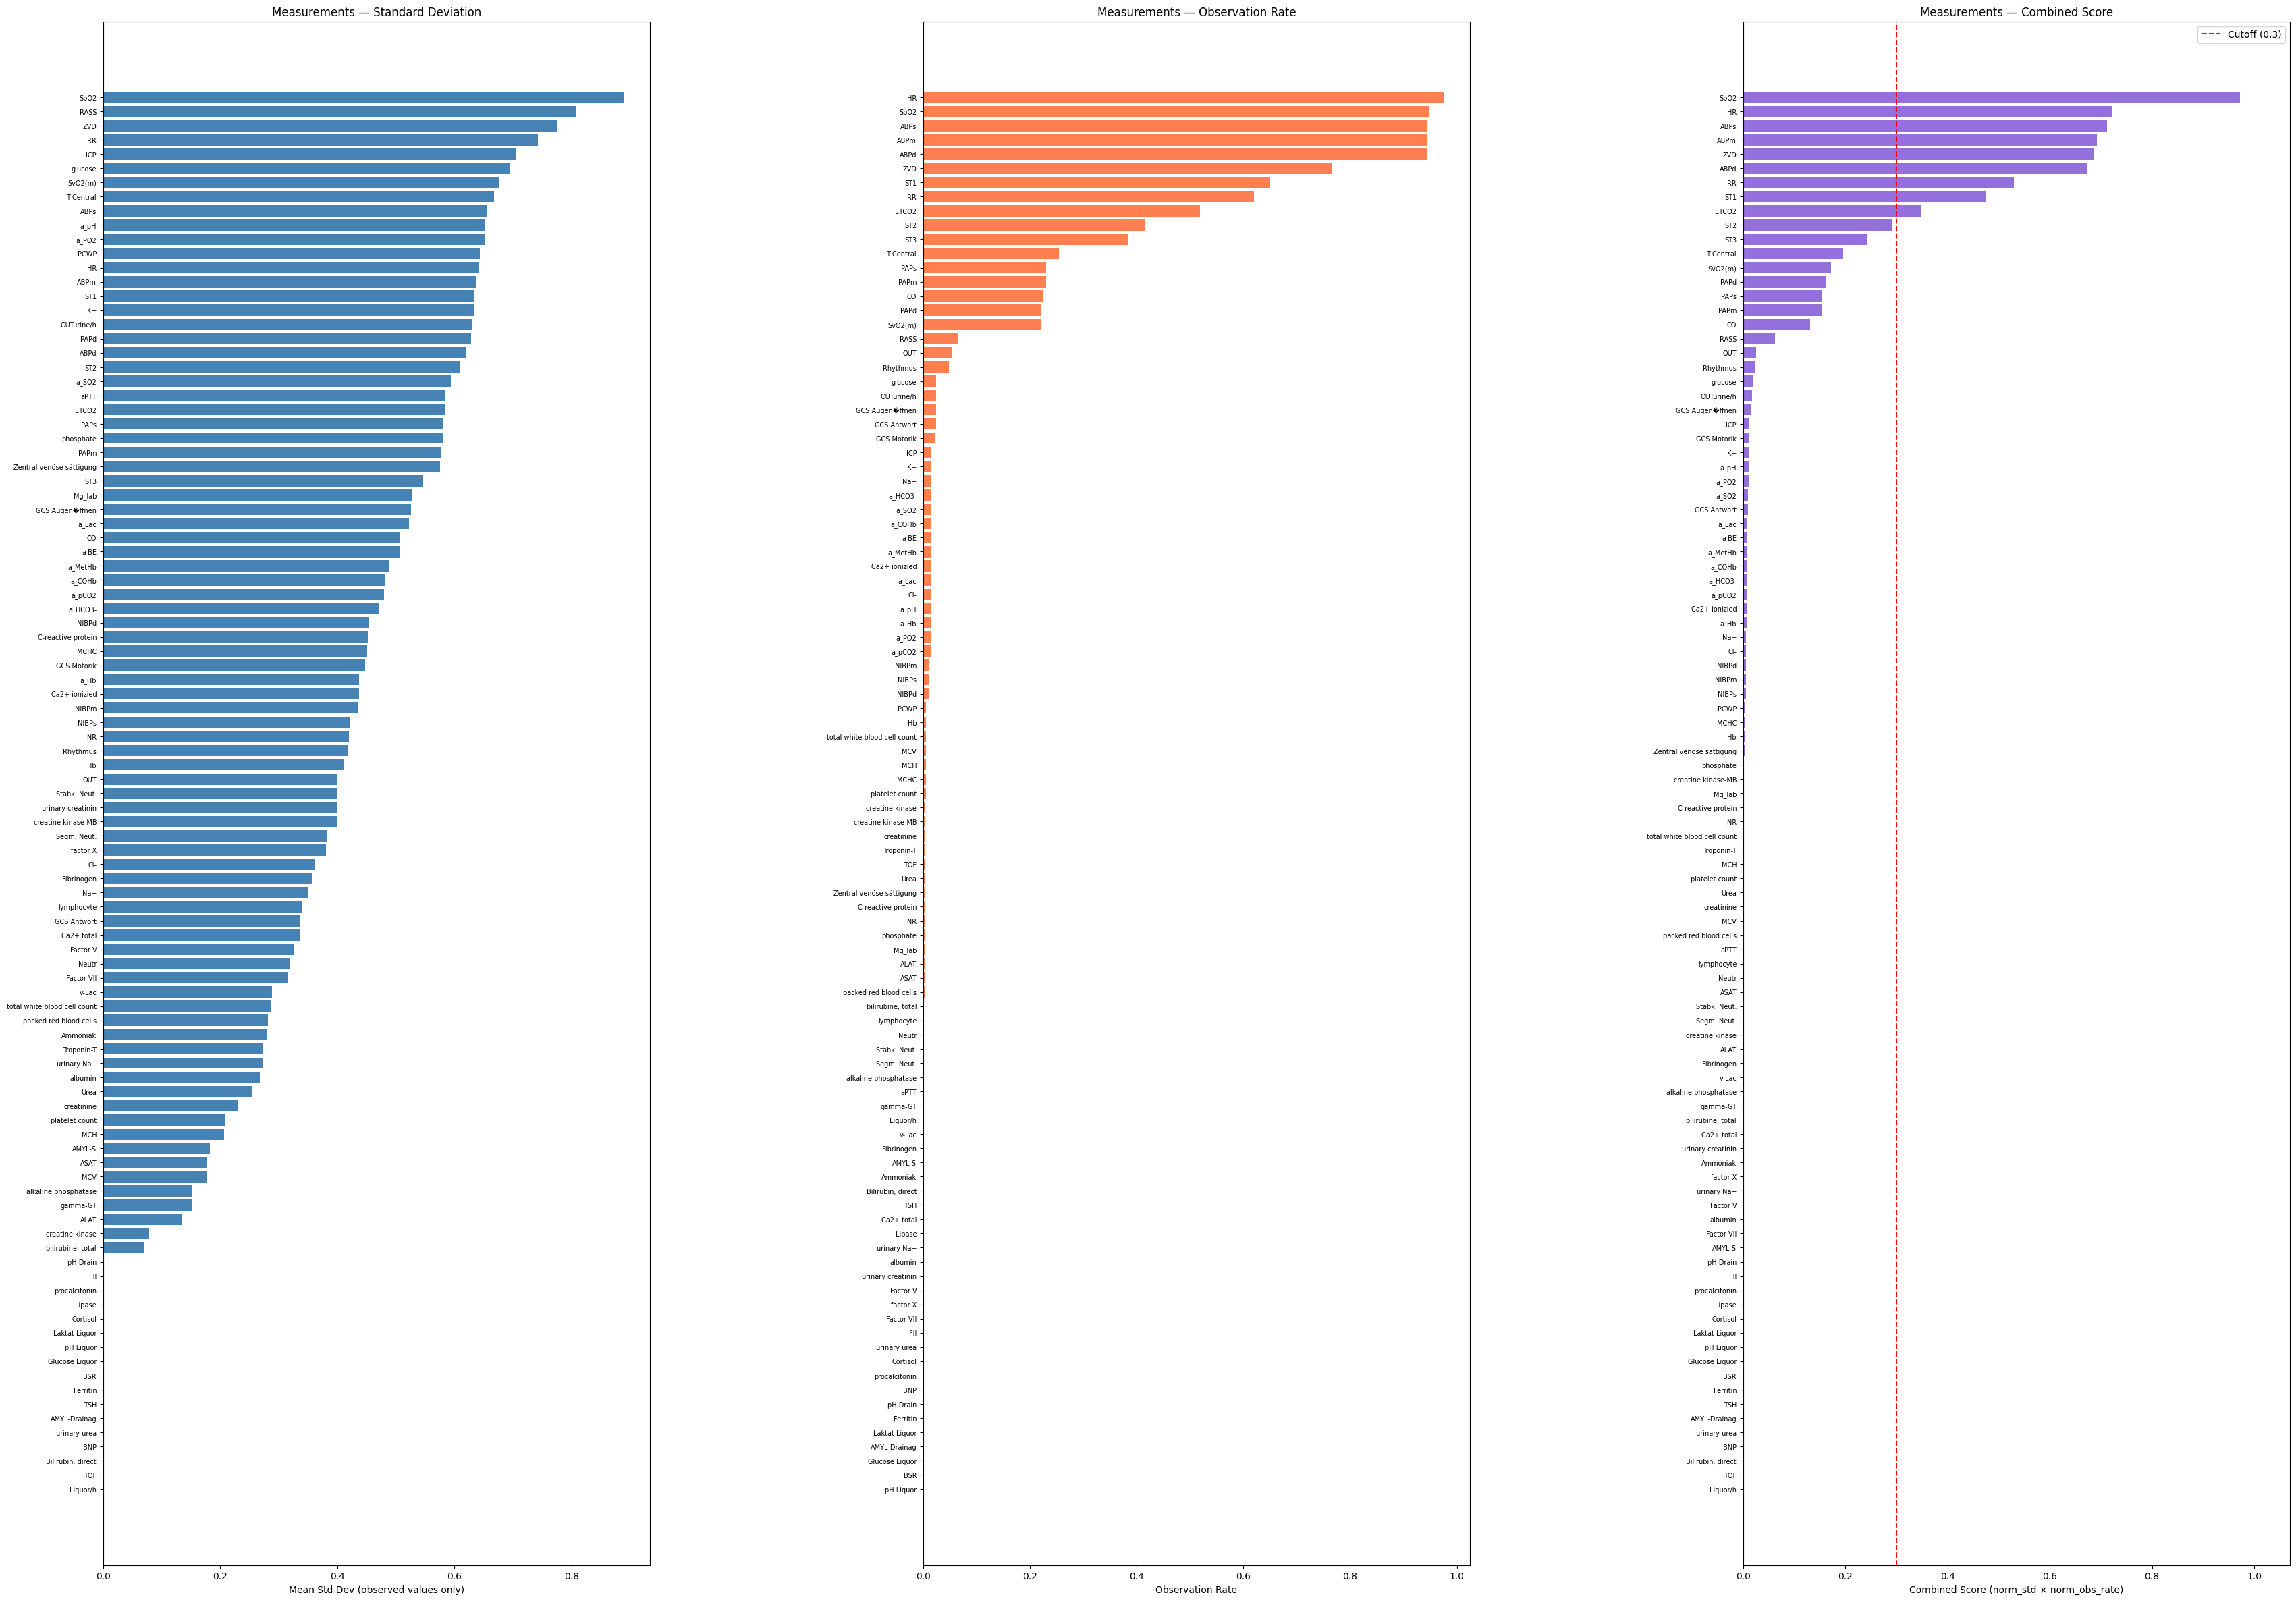


Measurements — 9 variables above cutoff 0.3:
   19 SpO2                                     score=0.9725
    0 HR                                       score=0.7217
    2 ABPs                                     score=0.7121
    4 ABPm                                     score=0.6925
   14 ZVD                                      score=0.6852
    3 ABPd                                     score=0.6742
   21 RR                                       score=0.5301
   15 ST1                                      score=0.4755
   20 ETCO2                                    score=0.3487

Measurements — Top 14:
   19 SpO2                                     score=0.9725
    0 HR                                       score=0.7217
    2 ABPs                                     score=0.7121
    4 ABPm                                     score=0.6925
   14 ZVD                                      score=0.6852
    3 ABPd                                     score=0.6742
   21 RR                      

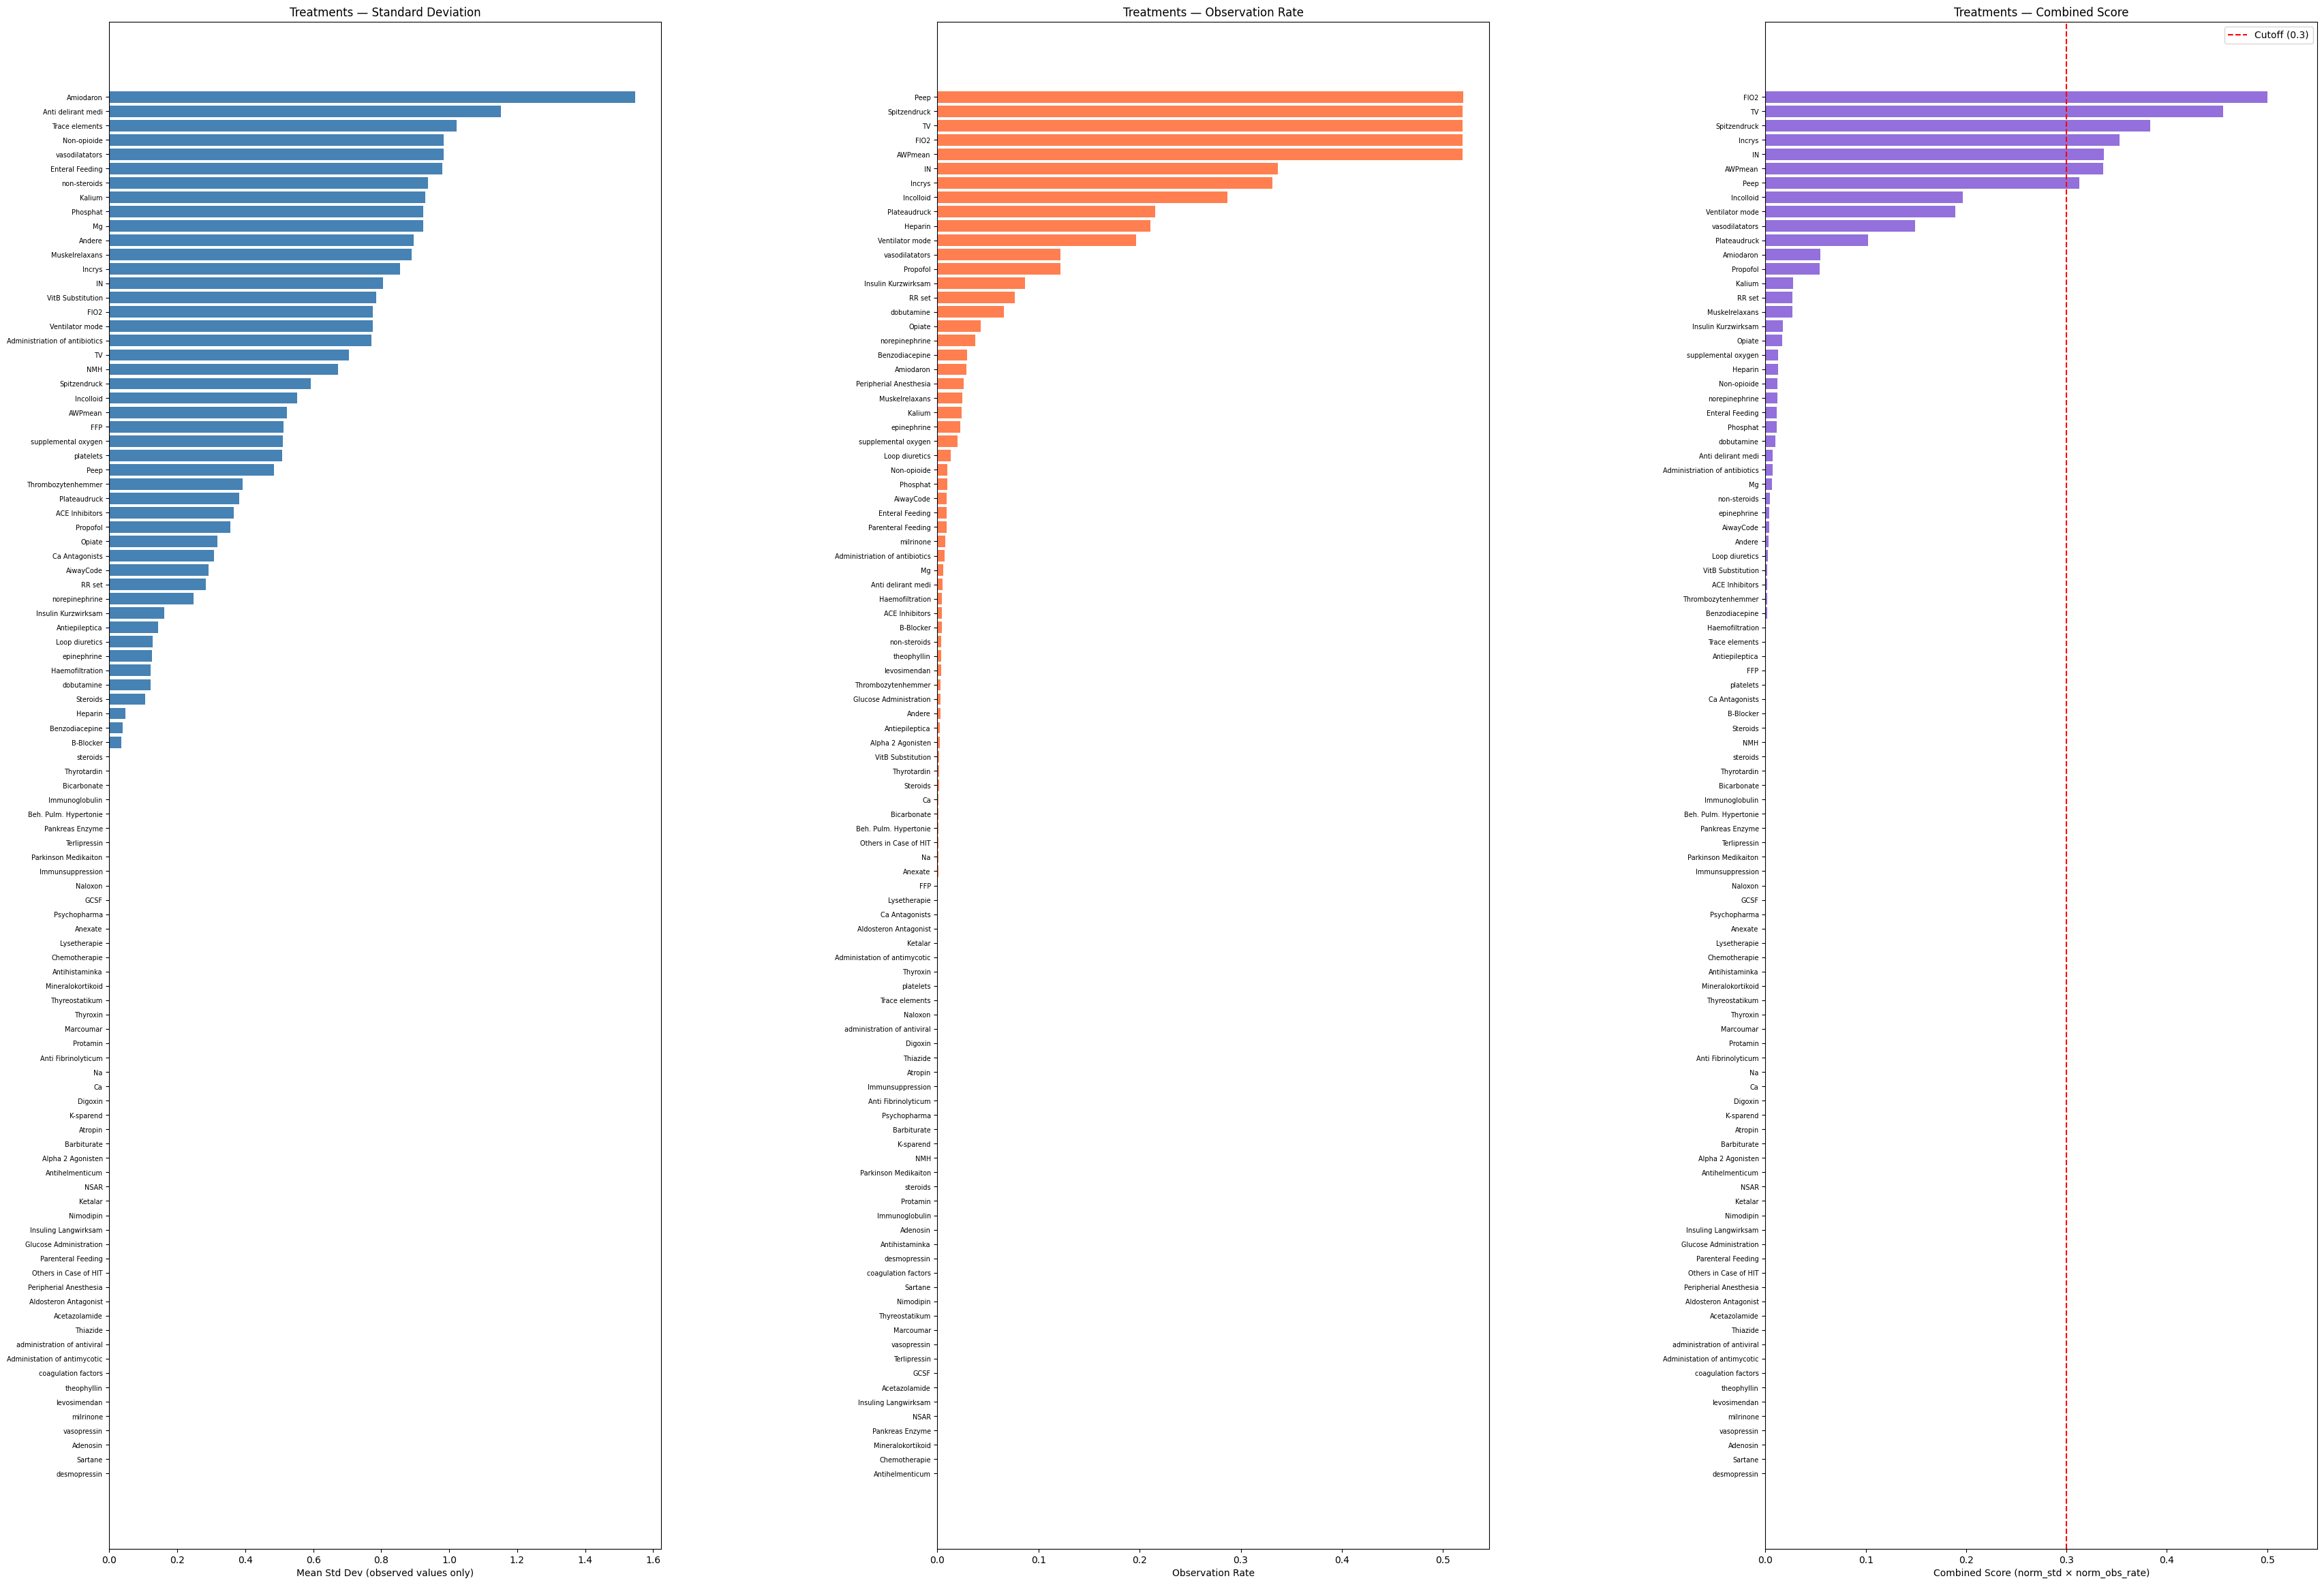


Treatments — 7 variables above cutoff 0.3:
    4 FIO2                                     score=0.5001
    7 TV                                       score=0.4557
    8 Spitzendruck                             score=0.3833
    2 Incrys                                   score=0.3530
    1 IN                                       score=0.3369
   10 AWPmean                                  score=0.3368
    5 Peep                                     score=0.3129

Treatments — Top 14:
    4 FIO2                                     score=0.5001
    7 TV                                       score=0.4557
    8 Spitzendruck                             score=0.3833
    2 Incrys                                   score=0.3530
    1 IN                                       score=0.3369
   10 AWPmean                                  score=0.3368
    5 Peep                                     score=0.3129
    3 Incolloid                                score=0.1965
    6 Ventilator mode             

In [18]:
plot_stats(measurement_names, m_stds, m_obs_rates, "Measurements")
plot_stats(treatment_names,   t_stds, t_obs_rates, "Treatments")


# Debugging

In [1]:
def compute_delta_t(mask_window):
    T, V = mask_window.shape
    delta = np.zeros((T, V), dtype=np.float32)

    for v in range(V):
        last_obs = -1
        for t in range(T):
            if mask_window[t, v] == 1:
                last_obs = t
                delta[t, v] = 0.0
            else:
                delta[t, v] = (t - last_obs) if last_obs >= 0 else (t + 1)

    return delta / T

In [2]:
import numpy as np

mask_window = [[1, 0, 1, 1, 0], [0, 0,0, 0, 1], [1, 1, 0, 1, 1]]
delta = compute_delta_t(np.array(mask_window))
print("Mask Window:\n", np.array(mask_window))
print("Delta T:\n", delta)

Mask Window:
 [[1 0 1 1 0]
 [0 0 0 0 1]
 [1 1 0 1 1]]
Delta T:
 [[0.         0.33333334 0.         0.         0.33333334]
 [0.33333334 0.6666667  0.33333334 0.33333334 0.        ]
 [0.         0.         0.6666667  0.         0.        ]]


In [ ]:
from data.dataset import HiRIDDataset, compute_delta_t
import numpy as np

# Load one sample
ds = HiRIDDataset(
    '/home/bbe9928/thesis_work/hirid_jepa/data/Cardiovascular_common_subset.h5',
    'train', context_steps=36, target_steps=36
)
sample = ds[0]

mask  = sample['context_mask'].numpy()  # (36, n_measurements)
delta = sample['delta_t'].numpy()       # (36, n_measurements)

# Check variable 0 (HR — most frequently observed)
print("HR mask:   ", mask[:, 0])
print("HR delta_t:", delta[:, 0])
print()
# Check a sparse variable (pick one with many zeros in mask)
sparse_var = np.argmin(mask.mean(axis=0))
print(f"Sparse var index: {sparse_var}")
print("mask:   ", mask[:, sparse_var])
print("delta_t:", delta[:, sparse_var])

TypeError: HiRIDDataset.compute_delta_t() takes 1 positional argument but 2 were given

In [3]:
import config
from data.dataset import HiRIDDataset, compute_delta_t

ds = HiRIDDataset(config.DATA_PATH, 'test', config.CONTEXT_STEPS, config.TARGET_STEPS)
sample = ds[0]
print("HR delta_t:", sample['delta_t'][:, 0])  # assuming HR is index 0
print("HR mask:", sample['context_mask'][:, 0])
print("HR measurements:", sample['measurements'][:, 0])

Precomputing delta_t...
Done.
HR delta_t: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
HR mask: tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])
HR measurements: tensor([ 0.0235,  0.0235,  0.5241,  0.0791,  0.0235,  0.0235,  0.9135,  0.5241,
         0.8579,  0.8579,  0.7466,  0.7466,  0.5241,  0.6910,  0.5241,  0.4685,
         0.3016,  0.2460,  0.4129,  0.1348,  0.4129,  0.0791,  0.3016,  0.2460,
         0.1904, -0.0321, -0.0877,  0.1348, -0.1990, -0.1990, -0.1434, -0.3102,
        -0.3659, -0.5327, -0.5884, -0.6440])


In [4]:
import torch
ckpt = torch.load('/home/bbe9928/thesis_work/hirid_jepa/checkpoints/gru_ctx36_tgt36_h256_l1_28_05_21-06.pt')
print(ckpt['config'])

{'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.3, 'target_steps': 36, 'encoder_dim': 64, 'n_measurements': 99, 'n_treatments': 97, 'measurement_subset': None, 'treatment_subset': None, 'uses_context_mask': True, 'uses_delta_t': True}


In [7]:
print(ckpt['config'].get('data_path', 'not saved'))


not saved
